# Feature Engineering - Week 6

This notebook adds property-level and geographic features to the Week 5 best
model, then compares the original and updated feature sets under the same
chronological evaluation:

- `PropertyAge` (retained from Week 5);
- `BedBathRatio`; and
- elementary, high-school, and unified district names from the California
  School District Areas 2024-25 boundary layer.

April 2026 is the validation month. May 2026 remains the final test month.

In [1]:
from pathlib import Path
import urllib.request

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
TARGET = "ClosePrice"
VALIDATION_MONTH = "2026-04"
TEST_MONTH = "2026-05"
PROJECT_ROOT = Path("..") if Path("../data/week3_drive").exists() else Path(".")
TRAIN_FILE = "crmls_sfr_train_X12_2025-05_to_2026-04.csv"
TEST_FILE = "crmls_sfr_test_2026-05.csv"
SCHOOL_DISTRICT_URL = (
    "https://gis.data.ca.gov/api/download/v1/items/"
    "b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
)
SCHOOL_FILE = Path(
    PROJECT_ROOT / "data/week6_reference/california_school_district_areas_2024_25.geojson"
)
OUTPUT_DIR = PROJECT_ROOT / "outputs/week6_feature_engineering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_data_file(file_name):
    candidates = [
        PROJECT_ROOT / "data/week3_drive" / file_name,
        Path("/content/drive/MyDrive") / file_name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        matches = list(drive_root.rglob(file_name))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"Could not find {file_name}. Mount Google Drive in Colab and add the "
        "shared IDX Summer Intern folder to My Drive."
    )


def ensure_school_boundaries():
    if SCHOOL_FILE.exists() and SCHOOL_FILE.stat().st_size > 1_000_000:
        return SCHOOL_FILE
    SCHOOL_FILE.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading official California school-district GeoJSON...")
    urllib.request.urlretrieve(SCHOOL_DISTRICT_URL, SCHOOL_FILE)
    return SCHOOL_FILE


try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

TRAIN_PATH = find_data_file(TRAIN_FILE)
TEST_PATH = find_data_file(TEST_FILE)
SCHOOL_PATH = ensure_school_boundaries()

## 1. Load and clean the versioned snapshot

In [2]:
history_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, low_memory=False)
assert history_raw["close_month"].min() == "2025-05"
assert history_raw["close_month"].max() == VALIDATION_MONTH
assert test_raw["close_month"].eq(TEST_MONTH).all()

RESTORABLE_NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "YearBuilt", "Latitude", "Longitude", "AssociationFee", "Stories", "GarageSpaces",
]


def restore_marked_missing_values(frame):
    restored = frame.copy()
    for feature in RESTORABLE_NUMERIC_FEATURES:
        flag = f"{feature}_was_missing"
        if flag in restored.columns:
            restored.loc[restored[flag].fillna(False).astype(bool), feature] = np.nan
    return restored


def clean_invalid_records(frame):
    cleaned = frame.copy()
    target = pd.to_numeric(cleaned[TARGET], errors="coerce")
    cleaned = cleaned.loc[target.notna() & target.gt(0)].copy()
    for feature, invalid in [
        ("LivingArea", "nonpositive"),
        ("BedroomsTotal", "negative"),
        ("BathroomsTotalInteger", "negative"),
    ]:
        values = pd.to_numeric(cleaned[feature], errors="coerce")
        mask = values.notna() & (values.le(0) if invalid == "nonpositive" else values.lt(0))
        cleaned = cleaned.loc[~mask].copy()
    close_date = pd.to_datetime(cleaned["CloseDate"], errors="coerce")
    list_date = pd.to_datetime(cleaned["ListingContractDate"], errors="coerce")
    cleaned = cleaned.loc[
        ~(close_date.notna() & list_date.notna() & close_date.lt(list_date))
    ].copy()
    return cleaned.drop_duplicates(subset=["ListingKey"], keep="first")


history_clean = clean_invalid_records(restore_marked_missing_values(history_raw))
test_clean = clean_invalid_records(restore_marked_missing_values(test_raw))
test_clean = test_clean.loc[
    ~test_clean["ListingKey"].isin(set(history_clean["ListingKey"].dropna()))
].copy()

snapshot = pd.DataFrame([
    {"role": "history", "rows": len(history_clean), "file": TRAIN_PATH.name},
    {"role": "test", "rows": len(test_clean), "file": TEST_PATH.name},
])
display(snapshot)

,role,rows,file
0,history,129669,crmls_sfr_train_X12_2025-05_to_2026-04.csv
1,test,12008,crmls_sfr_test_2026-05.csv


## 2. Spatially join each property to school-district boundaries

California may have overlapping elementary and secondary districts. Keeping one
feature per district type preserves that structure without duplicating property
rows. If multiple polygons of the same type match a boundary point, their names
are sorted and combined deterministically.

In [3]:
DISTRICT_FEATURES = [
    "SchoolDistrictElementary",
    "SchoolDistrictHigh",
    "SchoolDistrictUnified",
]


def build_coordinate_district_lookup(frames, boundaries_path):
    coordinates = pd.concat(
        [f[["Latitude", "Longitude"]] for f in frames], ignore_index=True
    ).apply(pd.to_numeric, errors="coerce").dropna().drop_duplicates()
    coordinates = coordinates.loc[
        coordinates["Latitude"].between(32, 43)
        & coordinates["Longitude"].between(-125, -113)
    ].reset_index(drop=True)
    coordinates["_coordinate_id"] = np.arange(len(coordinates))

    points = gpd.GeoDataFrame(
        coordinates,
        geometry=gpd.points_from_xy(coordinates["Longitude"], coordinates["Latitude"]),
        crs="EPSG:4326",
    )
    districts = gpd.read_file(
        boundaries_path,
        columns=["DistrictName", "DistrictType", "geometry"],
    ).to_crs(points.crs)
    joined = gpd.sjoin(points, districts, how="left", predicate="intersects")

    district_type_map = {
        "Elementary": "SchoolDistrictElementary",
        "High": "SchoolDistrictHigh",
        "Unified": "SchoolDistrictUnified",
    }
    joined["feature"] = joined["DistrictType"].map(district_type_map)
    matched = joined.dropna(subset=["feature", "DistrictName"]).copy()
    grouped = (
        matched.groupby(["_coordinate_id", "feature"])["DistrictName"]
        .agg(lambda values: " | ".join(sorted(set(map(str, values)))))
        .unstack()
    )
    lookup = coordinates.join(grouped, on="_coordinate_id")
    for feature in DISTRICT_FEATURES:
        if feature not in lookup:
            lookup[feature] = np.nan
    return lookup[["Latitude", "Longitude"] + DISTRICT_FEATURES]


district_lookup = build_coordinate_district_lookup(
    [history_clean, test_clean], SCHOOL_PATH
)
display(pd.DataFrame({
    "feature": DISTRICT_FEATURES,
    "coverage": [district_lookup[f].notna().mean() for f in DISTRICT_FEATURES],
}).round(4))


def add_district_features(frame, lookup):
    featured = frame.copy()
    featured["_latitude_key"] = pd.to_numeric(featured["Latitude"], errors="coerce")
    featured["_longitude_key"] = pd.to_numeric(featured["Longitude"], errors="coerce")
    renamed = lookup.rename(columns={
        "Latitude": "_latitude_key", "Longitude": "_longitude_key"
    })
    return featured.merge(
        renamed, on=["_latitude_key", "_longitude_key"], how="left", validate="many_to_one"
    ).drop(columns=["_latitude_key", "_longitude_key"])


history_geo = add_district_features(history_clean, district_lookup)
test_geo = add_district_features(test_clean, district_lookup)
assert len(history_geo) == len(history_clean)
assert len(test_geo) == len(test_clean)

,feature,coverage
0,SchoolDistrictElementary,0.2457
1,SchoolDistrictHigh,0.2403
2,SchoolDistrictUnified,0.7589


## 3. Engineer property age and bed/bath ratio

In [4]:
def engineer_features(frame):
    engineered = frame.copy()
    sale_month = pd.to_datetime(engineered["close_month"], format="%Y-%m", errors="coerce")
    year_built = pd.to_numeric(engineered["YearBuilt"], errors="coerce")
    bedrooms = pd.to_numeric(engineered["BedroomsTotal"], errors="coerce")
    bathrooms = pd.to_numeric(engineered["BathroomsTotalInteger"], errors="coerce")
    engineered["PropertyAge"] = (sale_month.dt.year - year_built).where(
        year_built.gt(0) & year_built.le(sale_month.dt.year)
    )
    engineered["BedBathRatio"] = (bedrooms / bathrooms).where(
        bedrooms.ge(0) & bathrooms.gt(0)
    )
    engineered["SaleMonthSin"] = np.sin(2 * np.pi * sale_month.dt.month / 12)
    engineered["SaleMonthCos"] = np.cos(2 * np.pi * sale_month.dt.month / 12)
    return engineered


history = engineer_features(history_geo)
test = engineer_features(test_geo)
display(history[["PropertyAge", "BedBathRatio"]].describe().round(2))

,PropertyAge,BedBathRatio
count,129581.00,129618.00
mean,49.52,1.46
std,27.58,0.47
min,0.00,0.00
25%,27.00,1.00
50%,49.00,1.50
75%,70.00,1.50
max,225.00,7.50


## 4. Define a fair old-vs-new feature comparison

The old set exactly matches Week 5. The new set adds `BedBathRatio` and the
three school-district categories. The Random Forest configuration is fixed to
the Week 5-selected candidate; no May result is used for tuning.

In [5]:
BASE_NUMERIC = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "Latitude", "Longitude", "AssociationFee", "Stories", "GarageSpaces",
    "PropertyAge", "SaleMonthSin", "SaleMonthCos",
]
BASE_CATEGORICAL = ["PostalCode", "City", "PropertySubType"]
FEATURE_SETS = {
    "Week 5 features": (BASE_NUMERIC, BASE_CATEGORICAL),
    "Week 6 engineered features": (
        BASE_NUMERIC + ["BedBathRatio"],
        BASE_CATEGORICAL + DISTRICT_FEATURES,
    ),
}


def build_pipeline(numeric_features, categorical_features):
    preprocessing = ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore", min_frequency=50, sparse_output=True
            )),
        ]), categorical_features),
    ])
    model = RandomForestRegressor(
        n_estimators=100, max_depth=24, min_samples_leaf=3, max_features=0.5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )
    return Pipeline([("preprocessing", preprocessing), ("model", model)])


def fit_closeprice_bounds(frame):
    return tuple(map(float, frame[TARGET].quantile([0.005, 0.995])))


def apply_bounds(frame, bounds):
    return frame.loc[frame[TARGET].between(*bounds, inclusive="both")].copy()


def evaluate(y_true, y_pred):
    ape = np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true))
    return {
        "r2": r2_score(y_true, y_pred),
        "mape": ape.mean(),
        "mdape": np.median(ape),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
    }

## 5. Validate on April, then refit and evaluate May once

In [6]:
development_raw = history.loc[history["close_month"] < VALIDATION_MONTH].copy()
validation_raw = history.loc[history["close_month"] == VALIDATION_MONTH].copy()
validation_bounds = fit_closeprice_bounds(development_raw)
development = apply_bounds(development_raw, validation_bounds)
validation = apply_bounds(validation_raw, validation_bounds)

validation_rows = []
for feature_set, (numeric, categorical) in FEATURE_SETS.items():
    model = build_pipeline(numeric, categorical)
    model.fit(development, development[TARGET])
    validation_rows.append({
        "feature_set": feature_set,
        "split": "April 2026 validation",
        **evaluate(validation[TARGET], model.predict(validation)),
    })
validation_comparison = pd.DataFrame(validation_rows)
display(validation_comparison.round(4))

test_bounds = fit_closeprice_bounds(history)
final_train = apply_bounds(history, test_bounds)
final_test = apply_bounds(test, test_bounds)

models = {}
test_predictions = {}
test_rows = []
for feature_set, (numeric, categorical) in FEATURE_SETS.items():
    model = build_pipeline(numeric, categorical)
    model.fit(final_train, final_train[TARGET])
    predictions = model.predict(final_test)
    models[feature_set] = model
    test_predictions[feature_set] = predictions
    test_rows.append({
        "feature_set": feature_set,
        "split": "May 2026 test",
        **evaluate(final_test[TARGET], predictions),
    })

test_comparison = pd.DataFrame(test_rows)
feature_set_comparison = pd.concat(
    [validation_comparison, test_comparison], ignore_index=True
)
old_test = test_comparison.loc[
    test_comparison["feature_set"].eq("Week 5 features")
].iloc[0]
new_test = test_comparison.loc[
    test_comparison["feature_set"].eq("Week 6 engineered features")
].iloc[0]
test_comparison["r2_change_vs_week5"] = test_comparison["r2"] - old_test["r2"]
test_comparison["mdape_reduction_vs_week5"] = old_test["mdape"] - test_comparison["mdape"]
display(test_comparison.round(4))

,feature_set,split,r2,mape,mdape,mae,rmse
0,Week 5 features,April 2026 validation,0.8706,0.1331,0.0839,175469.5549,356147.3757
1,Week 6 engineered features,April 2026 validation,0.8705,0.1325,0.0838,175244.3877,356301.8036


,feature_set,split,r2,mape,mdape,mae,rmse,r2_change_vs_week5,mdape_reduction_vs_week5
0,Week 5 features,May 2026 test,0.8640,0.1323,0.0832,179739.6134,367448.3707,0.0000,0.0000
1,Week 6 engineered features,May 2026 test,0.8669,0.1315,0.0829,178391.8477,363599.9967,0.0028,0.0003


## 6. Save the comparison table, predictions, and chart

In [7]:
feature_set_comparison.to_csv(
    OUTPUT_DIR / "old_vs_new_feature_sets.csv", index=False
)
district_coverage = pd.DataFrame({
    "district_feature": DISTRICT_FEATURES,
    "history_coverage": [history[f].notna().mean() for f in DISTRICT_FEATURES],
    "test_coverage": [test[f].notna().mean() for f in DISTRICT_FEATURES],
})
district_coverage.to_csv(OUTPUT_DIR / "school_district_coverage.csv", index=False)

predictions = pd.DataFrame({
    "ListingKey": final_test["ListingKey"].to_numpy(),
    "actual_close_price": final_test[TARGET].to_numpy(),
    "week5_prediction": test_predictions["Week 5 features"],
    "week6_prediction": test_predictions["Week 6 engineered features"],
})
predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

plot = test_comparison.set_index("feature_set")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot["r2"].plot.bar(ax=axes[0], color=["#8da0cb", "#66c2a5"])
axes[0].set(title="May 2026 test R2", xlabel="", ylabel="R2")
(plot["mdape"] * 100).plot.bar(ax=axes[1], color=["#8da0cb", "#66c2a5"])
axes[1].set(title="May 2026 test MdAPE", xlabel="", ylabel="MdAPE (%)")
for axis in axes:
    axis.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "old_vs_new_feature_sets.png", dpi=160)
plt.close()

## Final result

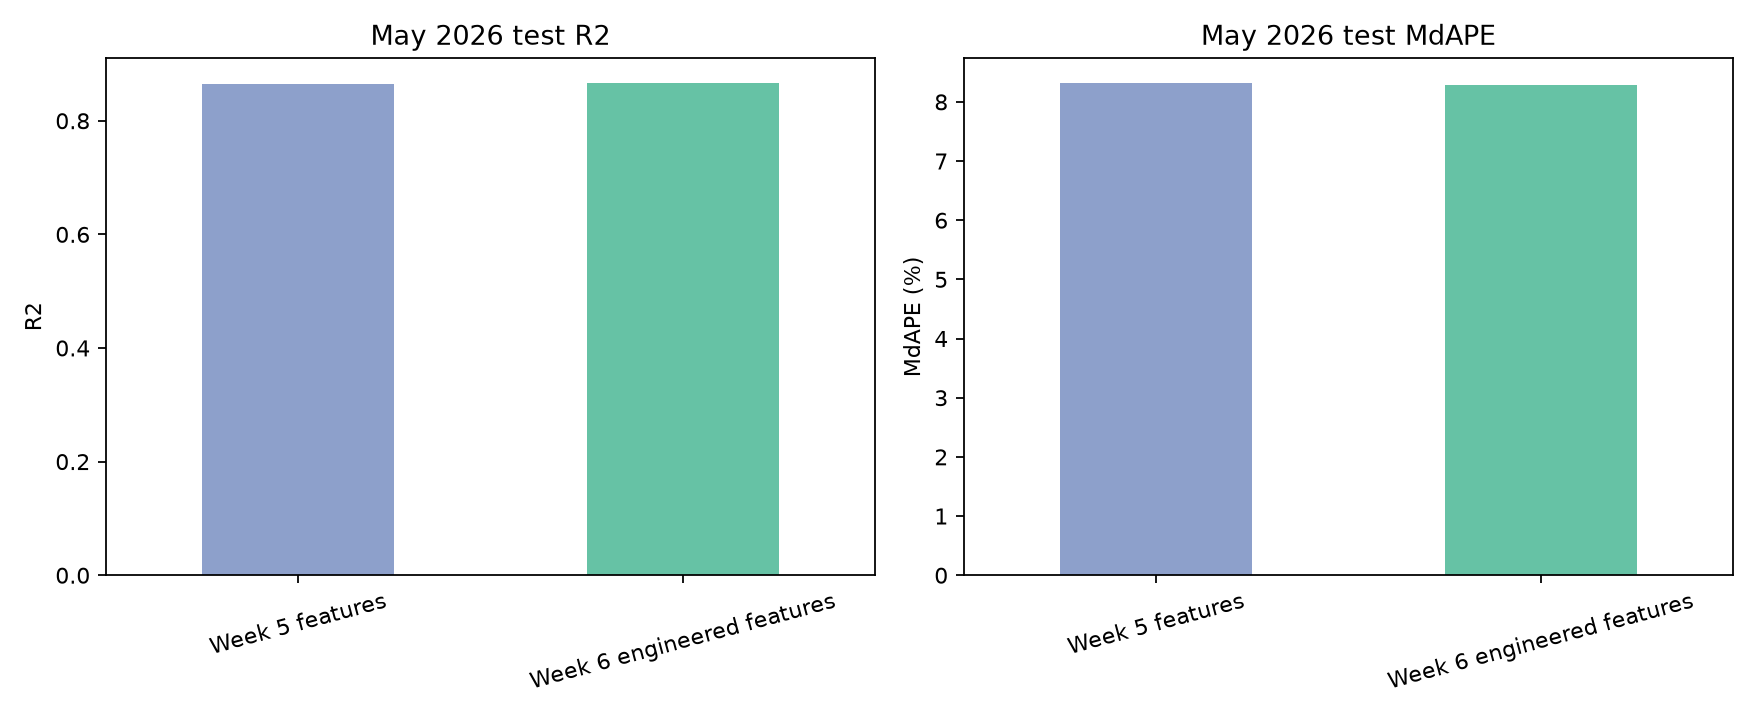

In [8]:
from IPython.display import Image

display(Image(filename=OUTPUT_DIR / "old_vs_new_feature_sets.png"))

## Conclusion

The table above is the required old-vs-new comparison. Because both rows use the
same chronological split, outlier rule, preprocessing, and fixed Random Forest
settings, the difference isolates the incremental value of the Week 6 feature
set. School-district coverage is reported separately so geographic matching
quality is transparent.